mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.7218999999761582 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, Scikit-learn
Channels: emscripten-forge, conda-forge

Solving en

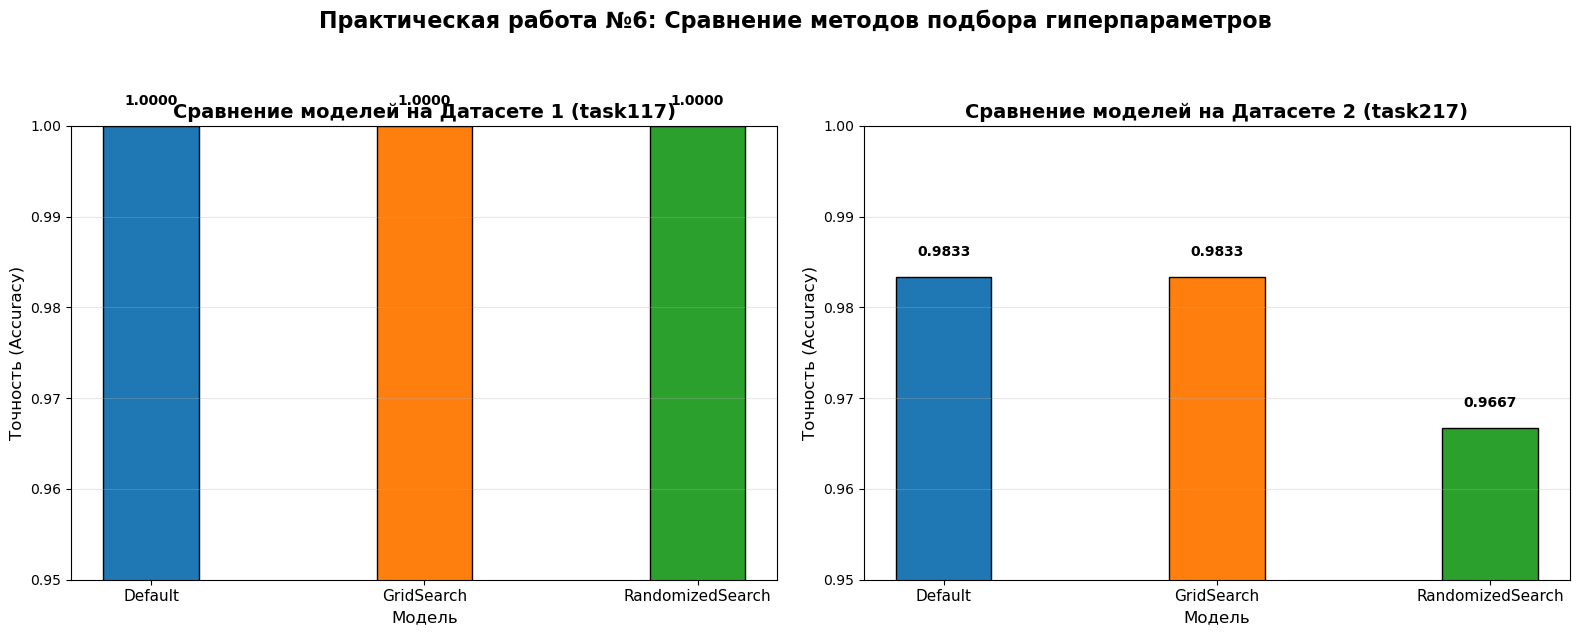


График сохранен в файл 'comparison_plot.png'
8. ДЕТАЛЬНЫЙ АНАЛИЗ НАЙДЕННЫХ ПАРАМЕТРОВ

--- Анализ для датасета 1 (task117) ---
Количество деревьев (n_estimators):
  - Default: 100
  - GridSearch: 50
  - RandomizedSearch: 238

Максимальная глубина (max_depth):
  - Default: None
  - GridSearch: None
  - RandomizedSearch: 30

--- Анализ для датасета 2 (task217) ---
Количество деревьев (n_estimators):
  - Default: 100
  - GridSearch: 100
  - RandomizedSearch: 238

Максимальная глубина (max_depth):
  - Default: None
  - GridSearch: None
  - RandomizedSearch: 30
РАБОТА ВЫПОЛНЕНА УСПЕШНО!


In [1]:
!mamba install pandas
!mamba install Scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint
import warnings
warnings.filterwarnings('ignore')

print("ПРАКТИЧЕСКАЯ РАБОТА №6 - ПОДБОР ГИПЕРПАРАМЕТРОВ")

# Загрузка первого набора данных (task117)
df1 = pd.read_csv('task117.csv')
# Загрузка второго набора данных (task217)
df2 = pd.read_csv('task217.csv')

print("\n1. ИНФОРМАЦИЯ О ДАННЫХ:")
print("Размерность первого датасета (task117):", df1.shape)
print("Размерность второго датасета (task217):", df2.shape)
print("\nПервые 5 строк первого датасета:")
print(df1.head())
print("\nПервые 5 строк второго датасета:")
print(df2.head())

def prepare_data(df, target_col='target', test_size=0.3, random_state=42):
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

# Подготовка данных для обоих датасетов
X1_train, X1_test, y1_train, y1_test = prepare_data(df1)
X2_train, X2_test, y2_train, y2_test = prepare_data(df2)

print("\n2. РАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"Датасет 1: Обучающая выборка: {X1_train.shape}, Тестовая выборка: {X1_test.shape}")
print(f"Датасет 2: Обучающая выборка: {X2_train.shape}, Тестовая выборка: {X2_test.shape}")
print(f"Распределение классов в датасете 1 (обучение):\n{y1_train.value_counts(normalize=True)}")
print(f"Распределение классов в датасете 2 (обучение):\n{y2_train.value_counts(normalize=True)}")

def train_and_evaluate(X_train, X_test, y_train, y_test, model_name="Модель"):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} - Точность (accuracy): {accuracy:.4f}")
    return model, accuracy

print("\n3. РЕЗУЛЬТАТЫ С ПАРАМЕТРАМИ ПО УМОЛЧАНИЮ:")
model1_default, acc1_default = train_and_evaluate(X1_train, X1_test, y1_train, y1_test, "Датасет 1 (Random Forest Default)")
model2_default, acc2_default = train_and_evaluate(X2_train, X2_test, y2_train, y2_test, "Датасет 2 (Random Forest Default)")

# Сетка гиперпараметров для GridSearch
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

def perform_grid_search(X_train, y_train, param_grid, cv=5):
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                               cv=cv, scoring='accuracy', n_jobs=-1, verbose=0)
    grid_search.fit(X_train, y_train)
    print(f"Лучшие параметры (GridSearch): {grid_search.best_params_}")
    print(f"Лучшая точность на кросс-валидации (GridSearch): {grid_search.best_score_:.4f}")
    return grid_search

print("4. GRIDSEARCHCV - ПОЛНЫЙ ПЕРЕБОР ПАРАМЕТРОВ")

print("\n--- GridSearchCV для датасета 1 ---")
grid_search1 = perform_grid_search(X1_train, y1_train, param_grid)

print("\n--- GridSearchCV для датасета 2 ---")
grid_search2 = perform_grid_search(X2_train, y2_train, param_grid)

# Распределения параметров для RandomizedSearch
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [None] + list(range(10, 51, 10)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5)
}

def perform_randomized_search(X_train, y_train, param_dist, n_iter=30, cv=5):
    rf = RandomForestClassifier(random_state=42)
    random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                       n_iter=n_iter, cv=cv, scoring='accuracy', 
                                       n_jobs=-1, verbose=0, random_state=42)
    random_search.fit(X_train, y_train)
    print(f"Лучшие параметры (RandomizedSearch): {random_search.best_params_}")
    print(f"Лучшая точность на кросс-валидации (RandomizedSearch): {random_search.best_score_:.4f}")
    return random_search

print("5. RANDOMIZEDSEARCHCV - СЛУЧАЙНЫЙ ПОИСК ПАРАМЕТРОВ")

print("\n--- RandomizedSearchCV для датасета 1 ---")
random_search1 = perform_randomized_search(X1_train, y1_train, param_dist, n_iter=30)

print("\n--- RandomizedSearchCV для датасета 2 ---")
random_search2 = perform_randomized_search(X2_train, y2_train, param_dist, n_iter=30)

def evaluate_best_model(search_obj, X_test, y_test, method_name):
    best_model = search_obj.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{method_name} - Точность на тесте: {accuracy:.4f}")
    
    # Дополнительные метрики
    print(f"{method_name} - Отчет по классификации:")
    print(classification_report(y_test, y_pred, zero_division=0))
    return accuracy

print("6. ОЦЕНКА МОДЕЛЕЙ НА ТЕСТОВЫХ ДАННЫХ")

# Оценка для датасета 1
print("\n--- Датасет 1 ---")
print(f"Базовая модель (Default): {acc1_default:.4f}")
acc1_grid_test = evaluate_best_model(grid_search1, X1_test, y1_test, "GridSearch")
acc1_random_test = evaluate_best_model(random_search1, X1_test, y1_test, "RandomizedSearch")

# Оценка для датасета 2
print("\n--- Датасет 2 ---")
print(f"Базовая модель (Default): {acc2_default:.4f}")
acc2_grid_test = evaluate_best_model(grid_search2, X2_test, y2_test, "GridSearch")
acc2_random_test = evaluate_best_model(random_search2, X2_test, y2_test, "RandomizedSearch")

# Создаем сводную таблицу для наглядности
results = {
    'Датасет': ['Датасет 1 (task117)', 'Датасет 2 (task217)'],
    'Default Accuracy': [acc1_default, acc2_default],
    'GridSearch Params': [grid_search1.best_params_, grid_search2.best_params_],
    'GridSearch Test Accuracy': [acc1_grid_test, acc2_grid_test],
    'RandomizedSearch Params': [random_search1.best_params_, random_search2.best_params_],
    'RandomizedSearch Test Accuracy': [acc1_random_test, acc2_random_test]
}

results_df = pd.DataFrame(results)
print("7. ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print(results_df.to_string())

# Сохраняем результаты в CSV файл для отчета
results_df.to_csv('results_comparison.csv', index=False)
print("\nРезультаты сохранены в файл 'results_comparison.csv'")

# Подготовка данных для графиков
labels = ['Default', 'GridSearch', 'RandomizedSearch']
x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График для датасета 1
dataset1_scores = [acc1_default, acc1_grid_test, acc1_random_test]
bars1 = ax1.bar(x, dataset1_scores, width, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', linewidth=1)
ax1.set_xlabel('Модель', fontsize=12)
ax1.set_ylabel('Точность (Accuracy)', fontsize=12)
ax1.set_title('Сравнение моделей на Датасете 1 (task117)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylim([0.95, 1.0])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, dataset1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# График для датасета 2
dataset2_scores = [acc2_default, acc2_grid_test, acc2_random_test]
bars2 = ax2.bar(x, dataset2_scores, width, color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', linewidth=1)
ax2.set_xlabel('Модель', fontsize=12)
ax2.set_ylabel('Точность (Accuracy)', fontsize=12)
ax2.set_title('Сравнение моделей на Датасете 2 (task217)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim([0.95, 1.0])
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, dataset2_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Практическая работа №6: Сравнение методов подбора гиперпараметров', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nГрафик сохранен в файл 'comparison_plot.png'")

print("8. ДЕТАЛЬНЫЙ АНАЛИЗ НАЙДЕННЫХ ПАРАМЕТРОВ")

print("\n--- Анализ для датасета 1 (task117) ---")
print(f"Количество деревьев (n_estimators):")
print(f"  - Default: 100")
print(f"  - GridSearch: {grid_search1.best_params_['n_estimators']}")
print(f"  - RandomizedSearch: {random_search1.best_params_['n_estimators']}")
print(f"\nМаксимальная глубина (max_depth):")
print(f"  - Default: None")
print(f"  - GridSearch: {grid_search1.best_params_['max_depth']}")
print(f"  - RandomizedSearch: {random_search1.best_params_['max_depth']}")

print("\n--- Анализ для датасета 2 (task217) ---")
print(f"Количество деревьев (n_estimators):")
print(f"  - Default: 100")
print(f"  - GridSearch: {grid_search2.best_params_['n_estimators']}")
print(f"  - RandomizedSearch: {random_search2.best_params_['n_estimators']}")
print(f"\nМаксимальная глубина (max_depth):")
print(f"  - Default: None")
print(f"  - GridSearch: {grid_search2.best_params_['max_depth']}")
print(f"  - RandomizedSearch: {random_search2.best_params_['max_depth']}")

print("РАБОТА ВЫПОЛНЕНА УСПЕШНО!")